# Preprocessat
Primer preprocessem

🧠 1) HOW EVERYTHING RELATES (THE SCHEMA)

Right now you have 3 “layers” of data:

📦 A. Raw images (DICOM files)

Located in:

cbis_ddsm/raw/cbis_ddsm/<FOLDER>/<Study>/<Series>/*.dcm

Each .dcm = one image

📊 B. Case description CSVs (THE IMPORTANT ONES)

You have:

calc_case_description_*
mass_case_description_*

These are your labels + metadata

Each row = one lesion (abnormality)

🔗 C. The link between them (CRUCIAL)

Each row contains:

image file path → original image
cropped image file path → cropped lesion image
ROI mask file path → segmentation mask

👉 These paths map directly to your folders.

🧩 FULL RELATIONSHIP (THIS IS YOUR MENTAL MODEL)
PATIENT (patient_id)
   ↓
STUDY (StudyInstanceUID)
   ↓
SERIES (SeriesInstanceUID)
   ↓
IMAGE (.dcm file)
   ↑
CSV row (labels + metadata)

And more concretely:

CSV row
 ├── pathology → label (BENIGN / MALIGNANT)
 ├── image file path → full mammogram
 ├── cropped image file path → lesion crop
 └── ROI mask file path → segmentation
⚠️ IMPORTANT INSIGHT

👉 You should NOT use the full images first

Use:

cropped image file path (best for classification)
ROI mask file path (for segmentation or attention)

In [1]:
import matplotlib
import sklearn
import timm
import cv2
import gtda
import tqdm
import pydicom
import numpy as np
import yaml
import random
import torch 
from tqdm import tqdm
import pandas as pd

SEED = 2
np.random.seed(SEED)
random.seed(SEED)
print("All good ✅")

All good ✅


In [2]:
mass_train_df = pd.read_csv('data/raw/mass_case_description_train_set.csv')
mass_test_df = pd.read_csv('data/raw/mass_case_description_test_set.csv')
mass_train_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [3]:
calc_train_df = pd.read_csv('data/raw/calc_case_description_train_set.csv')
calc_test_df = pd.read_csv('data/raw/calc_case_description_test_set.csv')
calc_train_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [4]:
metadata_df = pd.read_csv('data/raw/metadata/metadata.csv')
metadata_df.head()

,PatientID,StudyInstanceUID,SeriesInstanceUID,Collection,FileSize,DownloadURL,S5cmdManifestPath,OriginalS5cmdURI,completion_status
0,Calc-Test_P_01004_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.265198230512455509519...,1.3.6.1.4.1.9590.100.1.2.294445047912407030012...,cbis_ddsm,23645061,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,success
1,Calc-Test_P_00038_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.291121996131431385353...,1.3.6.1.4.1.9590.100.1.2.188613955710170417803...,cbis_ddsm,14620630,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,success
2,Calc-Test_P_00041_LEFT_MLO_2,1.3.6.1.4.1.9590.100.1.2.372962290011068589008...,1.3.6.1.4.1.9590.100.1.2.399466258212646932018...,cbis_ddsm,22926678,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,success
3,Calc-Test_P_00038_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.161465562211359959230...,1.3.6.1.4.1.9590.100.1.2.419081637812053404913...,cbis_ddsm,14055890,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,success
4,Calc-Test_P_00485_LEFT_CC_3,1.3.6.1.4.1.9590.100.1.2.188175119112669404616...,1.3.6.1.4.1.9590.100.1.2.284547955212024760928...,cbis_ddsm,24814482,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,success


This is a really important design decision, and it directly affects your results and how strong your thesis looks.

Let’s be very clear:

You have:

Cropped image → the actual mammogram region
ROI mask → binary mask showing lesion location
🧠 Short answer (practical recommendation)

👉 Use:

ViT input → cropped image
Preprocessing → cropped image
TDA → cropped image (main) + optionally masked version (advanced)

👉 Use the ROI mask ONLY as guidance, not as main input (at least initially)

🔍 Why this is the correct baseline choice

Your thesis goal is:

Improve classification using preprocessing + TDA

NOT:

Build a segmentation-aware model

So:

The model should see the same type of input as prior work
ROI masks are extra information, not the core signal
📊 What each file represents
🖼️ Cropped image
Contains:
Tumor
Surrounding tissue
What models usually train on

👉 This is your primary input

🎯 ROI mask
Binary (0/1)
Highlights lesion area

👉 This is spatial prior knowledge

⚙️ How to use them properly
✅ 1. Visual Transformer (ViT)

Use:

INPUT = cropped image

Why:

ViT expects natural image-like input
Mask alone has no texture → useless for classification
✅ 2. Preprocessing

Apply preprocessing to:

cropped image ONLY

Example:

CLAHE
Denoising

👉 Do NOT preprocess the mask

⚠️ 3. TDA — this is where it gets interesting

You have 3 possible strategies:

🥇 Option A (recommended baseline)

👉 TDA on raw cropped image

image → persistence diagram → persistence image

✔ Simple
✔ Matches your thesis description
✔ Works well

🥈 Option B (better, still clean)

👉 Apply mask BEFORE TDA:

masked_image = image * ROI_mask

Then:

masked_image → TDA

✔ Focuses topology on lesion
✔ Removes background noise
✔ Very relevant for medical images

👉 This is a strong experiment idea

🥉 Option C (advanced / bonus)

Use BOTH:

TDA on full image
TDA on masked image

Then concatenate features

👉 This becomes a nice contribution if you have time

You asked:

should I use calc or mass?

👉 Start with MASS only

Why:

Mass lesions have clearer structure → better for both ViT and TDA
Calcifications are:
smaller
noisier
harder → can hurt early experiments

👉 Strategy:

Phase 1: MASS (E1–E8)
Phase 2 (optional): add CALC as extension

Experiments:

Experiment Design

   Constants across all experiments

   - Dataset: CBIS-DDSM, respecting the official train/test split (you criticized others for not doing this — you should)
   - Model backbone: ViT-B/16, pretrained on ImageNet, fine-tuned
   - Input size: 224×224
   - Metrics: Accuracy, F1, AUC (as in your thesis)
   - Training: Same optimizer, learning rate, epochs, batch size, early stopping criteria across all runs
   - Repetitions: At least 3 seeds per experiment for statistical significance (you'll want to report mean ± std)

   What varies

   ┌─────┬──────────────────┬──────────────────────┬────────────┬────────────────────────────────────────┬───────────────────────────────┐
   │ ID  │ Image fed to ViT │ Preprocessing        │ TDA branch │ TDA computed on                        │ Model class                   │
   ├─────┼──────────────────┼──────────────────────┼────────────┼────────────────────────────────────────┼───────────────────────────────┤
   │ E1  │ Raw ROI          │ ❌                   │ ❌         │ —                                      │ ViTClassifier                 │
   ├─────┼──────────────────┼──────────────────────┼────────────┼────────────────────────────────────────┼───────────────────────────────┤
   │ E2  │ Preprocessed ROI │ ✅ (CLAHE + denoise) │ ❌         │ —                                      │ ViTClassifier                 │
   ├─────┼──────────────────┼──────────────────────┼────────────┼────────────────────────────────────────┼───────────────────────────────┤
   │ E3  │ Raw ROI          │ ❌                   │ ✅         │ Full ROI image                         │ FusionModel                   │
   ├─────┼──────────────────┼──────────────────────┼────────────┼────────────────────────────────────────┼───────────────────────────────┤
   │ E4  │ Preprocessed ROI │ ✅                   │ ✅         │ Full ROI image                         │ FusionModel                   │
   ├─────┼──────────────────┼──────────────────────┼────────────┼────────────────────────────────────────┼───────────────────────────────┤
   │ E5  │ Raw ROI          │ ❌                   │ ✅         │ Masked ROI (lesion only)               │ FusionModel                   │
   ├─────┼──────────────────┼──────────────────────┼────────────┼────────────────────────────────────────┼───────────────────────────────┤
   │ E6  │ Preprocessed ROI │ ✅                   │ ✅         │ Masked ROI                             │ FusionModel                   │
   ├─────┼──────────────────┼──────────────────────┼────────────┼────────────────────────────────────────┼───────────────────────────────┤
   │ E7  │ Raw ROI          │ ❌                   │ ✅         │ Both (full + masked, concatenated PIs) │ FusionModel (wider TDA input) │
   ├─────┼──────────────────┼──────────────────────┼────────────┼────────────────────────────────────────┼───────────────────────────────┤
   │ E8  │ Preprocessed ROI │ ✅                   │ ✅         │ Both                                   │ FusionModel (wider TDA input) │
   └─────┴──────────────────┴──────────────────────┴────────────┴────────────────────────────────────────┴───────────────────────────────┘

   Key design decisions to make

   1. What image goes into the pipeline?

   CBIS-DDSM gives you full mammograms + ROI masks + cropped ROI patches. I'd recommend using the cropped ROI patches (not full mammograms) as your base image for all experiments. Reasons:

   - Full mammograms are huge and mostly background — the ViT would waste capacity
   - The prior papers you reviewed all work with ROIs
   - It keeps the problem focused on classification, not detection

   2. What does "masked image" mean for E5–E8?

   CBIS-DDSM provides binary segmentation masks for each lesion. For the masked TDA input:

   - Take the cropped ROI image
   - Multiply it element-wise by the binary mask (pixels outside the lesion become 0)
   - Compute persistence on this masked image

   This means the TDA captures the topology of just the lesion tissue, ignoring surrounding breast tissue. The hypothesis is that lesion-specific topology (irregular boundaries, internal heterogeneity) is more discriminative than whole-ROI topology.

   3. Persistence image configuration

   You need to decide and fix:

   - Homology dimensions: Compute both H0 (connected components) and H1 (holes/loops). Concatenate both PIs into a single vector. H0 captures tissue density clusters; H1 captures ring-like structures and cavities.
   - PI resolution: Something like 20×20 per homology dimension → 400 per dimension → 800 total for full image. For E7/E8 (both full + masked), that doubles to 1600.
   - Weighting function: Linear ramp (standard choice from the Adams et al. paper you cite). Long-lived features get more weight.

   4. How E7/E8 differ from E5/E6

   The TDA input to the fusion model is the concatenation of two persistence image vectors:

   - PI from the full ROI image (captures context topology)
   - PI from the masked image (captures lesion-specific topology)

   This tests whether having both perspectives is better than either alone.

   What hypotheses each experiment tests

   - E1 vs E2 → Tests H1 (does preprocessing help?) in isolation
   - E1 vs E3 → Tests H2 (does TDA help?) in isolation
   - E2 vs E4 → Tests H2 when preprocessing is already applied
   - E3 vs E5 → Tests whether masked TDA is better than full-image TDA
   - E4 vs E6 → Same comparison, with preprocessing
   - E5 vs E7 → Tests whether adding full-image TDA on top of masked TDA helps
   - E6 vs E8 → The "kitchen sink" — does everything together beat the best subset?

   Statistical validation

   Since you're comparing 8 configurations, I'd suggest:

   - Run each experiment 3–5 times with different random seeds
   - Use a paired test (e.g., McNemar's test for accuracy, or DeLong's test for AUC) for pairwise comparisons
   - Report confidence intervals, not just point estimates

   What I'd flag as risks

   - TDA computation time — Cubical persistence on 224×224 images is manageable, but if you're computing it on-the-fly during training it'll be slow. I'd recommend precomputing all PIs and saving them as .npy files alongside the images.
   - Class imbalance — You mention it in the thesis. Decide upfront: weighted loss, oversampling, or both? Keep it consistent across all 8 experiments.
   - Small dataset — CBIS-DDSM has ~2,620 studies. With the official split and no augmentation, your test set is small. Consider data augmentation for the image branch (but not for TDA — augmenting then computing persistence is fine, computing persistence then augmenting is not meaningful).

   Want me to start implementing this experiment framework in the code?


## Reading images form memory and cacheing them


In [5]:
from src.utils.image_utils import cache_images_as_np_arrays

MASS_TRAIN_SAVE_DIR = "data/processed/mass_train"
MASS_TEST_SAVE_DIR = "data/processed/mass_test"

cache_images_as_np_arrays(MASS_TRAIN_SAVE_DIR, mass_train_df)
cache_images_as_np_arrays(MASS_TEST_SAVE_DIR, mass_test_df)

101it [00:00, 503.50it/s]

Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Training_P_00059_LEFT_CC_1\\1.3.6.1.4.1.9590.100.1.2.48879868112616314014628722363459317695\\1.3.6.1.4.1.9590.100.1.2.11686230612923981409805359571305102767\\aba0f538-8b5e-4289-82e1-d8af0cb4248c.dcm', 175992)])
Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Training_P_00059_LEFT_MLO_1\\1.3.6.1.4.1.9590.100.1.2.176451340112398457403861042321269517686\\1.3.6.1.4.1.9590.100.1.2.48416062411306564131997923171520794902\\43e489d6-4f53-4dc7-976d-1c324c0e2c77.dcm', 185858)])
Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Training_P_00108_LEFT_CC_1\\1.3.6.1.4.1.9590.100.1.2.140674184712922544700689875430083196185\\1.3.6.1.4.1.9590.100.1.2.1320034085133968626369

251it [00:00, 455.76it/s]

Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Training_P_00279_LEFT_CC_1\\1.3.6.1.4.1.9590.100.1.2.291491143010082707927596396962074171114\\1.3.6.1.4.1.9590.100.1.2.302043706512531689934596629952753769958\\2dcc4aa2-9d05-4906-b9d8-0bfe05b4abac.dcm', 753536)])
Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Training_P_00294_LEFT_CC_1\\1.3.6.1.4.1.9590.100.1.2.65513303911542795926723352792444052889\\1.3.6.1.4.1.9590.100.1.2.219157189212113616029573495392380980692\\e0cf89fb-7369-4db9-a8f4-1effb02efe90.dcm', 170326)])
Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Training_P_00294_LEFT_MLO_1\\1.3.6.1.4.1.9590.100.1.2.150922682011312294714357628673705031600\\1.3.6.1.4.1.9590.100.1.2.23520871661274218631

352it [00:00, 465.82it/s]

...

Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Test_P_00145_LEFT_CC_1\\1.3.6.1.4.1.9590.100.1.2.93042606812028734315141605334209390238\\1.3.6.1.4.1.9590.100.1.2.423283243012912888204847591923699853302\\b39e4f44-9d38-4b3a-a6f6-cdd82cc5fb58.dcm', 606572)])
Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Test_P_00145_LEFT_MLO_1\\1.3.6.1.4.1.9590.100.1.2.246933169112193643518141861462334002159\\1.3.6.1.4.1.9590.100.1.2.273736527812245924738896549683395645939\\c17e20aa-12f7-44da-8142-404144b7b4c8.dcm', 342126)])
Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Test_P_00192_RIGHT_CC_1\\1.3.6.1.4.1.9590.100.1.2.334722300310414240336095527691508293411\\1.3.6.1.4.1.9590.100.1.2.1418169443117430988183267240429

249it [00:00, 609.23it/s]

Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Test_P_00699_RIGHT_CC_1\\1.3.6.1.4.1.9590.100.1.2.38918671311748683823732245892550205854\\1.3.6.1.4.1.9590.100.1.2.67609098512679403432428254042416854686\\be2f4244-b5a7-4244-946e-7edb42cd73cf.dcm', 96024)])
Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Test_P_00699_RIGHT_MLO_1\\1.3.6.1.4.1.9590.100.1.2.203217338812796910527485190800565905979\\1.3.6.1.4.1.9590.100.1.2.271119365811925830039649727131876647231\\89187156-bd50-4d62-9d2f-28f1bfb3ed58.dcm', 113898)])
Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Test_P_00922_RIGHT_CC_1\\1.3.6.1.4.1.9590.100.1.2.70398258112919268818692673411660138722\\1.3.6.1.4.1.9590.100.1.2.11674080151332004713684346802408

378it [00:00, 597.93it/s]

Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Test_P_01595_LEFT_CC_1\\1.3.6.1.4.1.9590.100.1.2.404444414211923964309483104423598459071\\1.3.6.1.4.1.9590.100.1.2.166780450612529588140273491753803765092\\32ad54b4-aa91-4fe2-95bf-a50e65461189.dcm', 532084)])
Skipping: ('Unexpected amount of files in:', [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Test_P_01595_LEFT_MLO_1\\1.3.6.1.4.1.9590.100.1.2.208887696913173909908192759191681800195\\1.3.6.1.4.1.9590.100.1.2.2030047612135098214495507351416668765\\3208fee0-5644-422f-8669-fc799250d5d9.dcm', 509114)])


E1

end of e1

#### testing zone

Test 1: extract the ROI crop from the mamogram

In [6]:
import os
row = mass_train_df.iloc[0]
print("Image file path folder:", os.path.dirname(row['image file path'].strip()), sep='\n\t')
print("Cropped image path folder:", os.path.dirname(row['cropped image file path'].strip()), sep='\n\t')
print("ROI mask path folder:", os.path.dirname(row['ROI mask file path'].strip()), sep='\n\t')

Image file path folder:
	Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515
Cropped image path folder:
	Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650
ROI mask path folder:
	Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650


('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Training_P_00001_LEFT_CC_1\\1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106\\1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650\\692bee15-caa9-4170-84e3-0ef6f9f76959.dcm', 445022)
Mamogram crop shape:  (515, 431)
ROI crop shape:  (4808, 3024)
Mamogram shape:  (4808, 3024)


<Figure size 1000x1000 with 0 Axes>

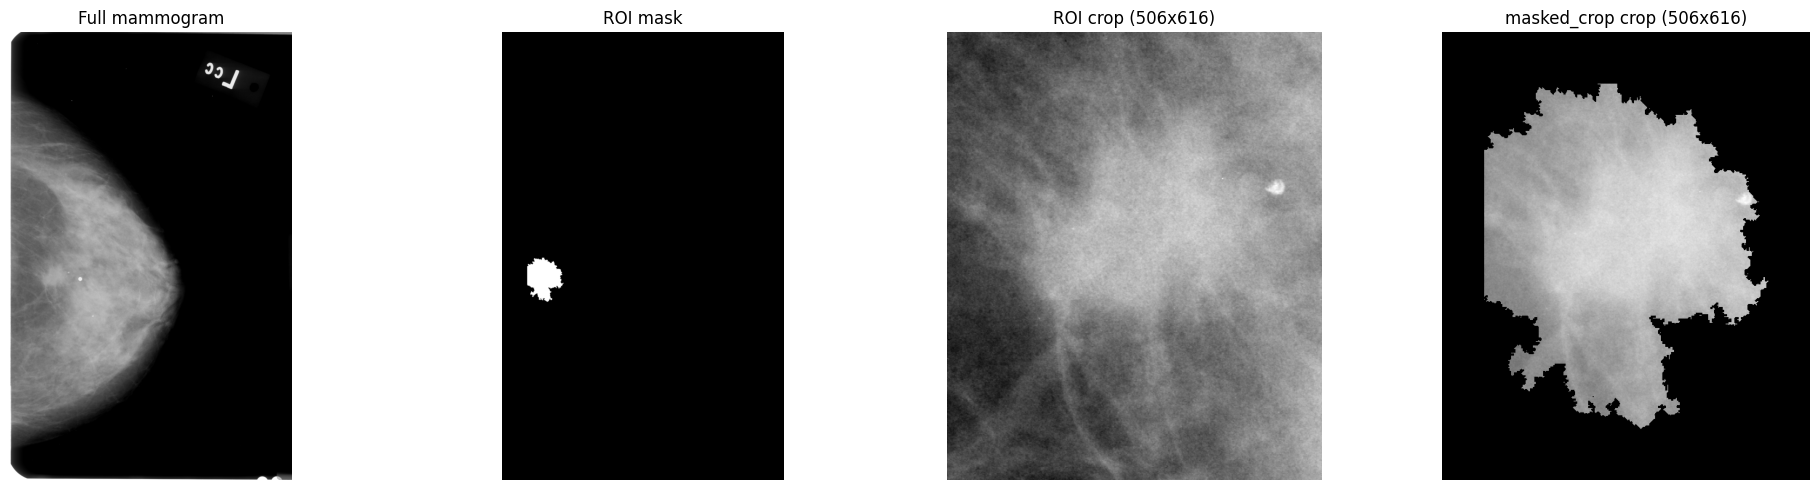

In [ ]:
import matplotlib.pyplot as plt
import os
from src.utils.image_utils import get_all_dcm_files_with_size, load_dicom, extract_roi_crop

dcm_files = get_all_dcm_files_with_size(row["cropped image file path"])
img_0_path = os.path.join(dcm_files[0][0])
img_0 = load_dicom(img_0_path)
img_1_path = os.path.join(dcm_files[1][0])
img_1 = load_dicom(img_1_path)

dcm_files = get_all_dcm_files_with_size(row["image file path"])

img_2_path = os.path.join(dcm_files[0][0])
img_2 = load_dicom(img_2_path)


roi_crop, masked_crop = extract_roi_crop(img_2, img_1)

plt.figure(figsize=(10,10))

print(f'Mamogram crop shape:  {img_0.shape}')
print(f'ROI crop shape:  {img_1.shape}')
print(f'Mamogram shape:  {img_2.shape}')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img, title in zip(axes,
    [img_2, img_1, img_0, masked_crop],
    ['Full mammogram', 'ROI mask',
     f'ROI crop ({roi_crop.shape[1]}x{roi_crop.shape[0]})',
     f'masked_crop crop ({masked_crop.shape[1]}x{masked_crop.shape[0]})']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

Test 2: proper training and validation

### Step 1: Precompute ROI crops from mammograms + masks
Run this once. It saves `.npy` files for each sample.

In [6]:
import pandas as pd
from src.datasets.experiment_dataset import ExperimentDataset
from src.models.vit_model import ViTClassifier
from src.training.experiment_runner import run_experiment

# Load the cached pre-cropped lesion paths from Step 1
train_cache = pd.read_csv('data/processed/mass_train/cached.csv')
test_cache = pd.read_csv('data/processed/mass_train/cached.csv')

results = {}

# --- E1: ViT baseline (no preprocessing, no TDA) ---
print('=== E1: ViT baseline ===')
train_ds = ExperimentDataset(
    roi_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    use_preprocessing=False, augment=True)
test_ds = ExperimentDataset(
    roi_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    use_preprocessing=False, augment=False)

results['E1'] = run_experiment(
    model_fn=ViTClassifier,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E1', 'seed': SEED, 'epochs': 2, 'patience': 5})

=== E1: ViT baseline ===
  [E1] Epoch 1/2  train_loss=0.7505  val_loss=0.7152  val_auc=0.4434
  [E1] Epoch 2/2  train_loss=0.7100  val_loss=0.6927  val_auc=0.4679
  [E1] TEST  acc=0.4967  f1=0.0000  auc=0.5557


### Step 2: Run experiments E1–E4
E1: ViT baseline (no preprocessing, no TDA)  
E2: ViT + preprocessing  
E3: ViT + TDA on full ROI  
E4: ViT + preprocessing + TDA on full ROI  

E3/E4 require precomputed persistence images (Step 2b below).  
Start with E1 and E2 which need no TDA.

In [ ]:
import pandas as pd
from src.datasets.experiment_dataset import ExperimentDataset
from src.models.vit_model import ViTClassifier
from src.training.experiment_runner import run_experiment

manifest = pd.read_csv('data/processed/roi_manifest.csv')
train_manifest = manifest[manifest['split'] == 'train'].reset_index(drop=True)
test_manifest = manifest[manifest['split'] == 'test'].reset_index(drop=True)

results = {}

# --- E1: ViT baseline ---
print('=== E1: ViT baseline ===')
train_ds = ExperimentDataset(
    roi_paths=train_manifest['roi_path'].tolist(),
    labels=train_manifest['label'].tolist(),
    use_preprocessing=False, augment=True)
test_ds = ExperimentDataset(
    roi_paths=test_manifest['roi_path'].tolist(),
    labels=test_manifest['label'].tolist(),
    use_preprocessing=False, augment=False)

results['E1'] = run_experiment(
    model_fn=ViTClassifier,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E1', 'seed': 42, 'epochs': 30, 'patience': 5})

# --- E2: ViT + preprocessing ---
print('\n=== E2: ViT + preprocessing ===')
train_ds = ExperimentDataset(
    roi_paths=train_manifest['roi_path'].tolist(),
    labels=train_manifest['label'].tolist(),
    use_preprocessing=True, augment=True)
test_ds = ExperimentDataset(
    roi_paths=test_manifest['roi_path'].tolist(),
    labels=test_manifest['label'].tolist(),import pandas as pd
from src.datasets.experiment_dataset import ExperimentDataset
from src.models.vit_model import ViTClassifier
from src.training.experiment_runner import run_experiment

# Load the cached pre-cropped lesion paths from Step 1
train_cache = pd.read_csv('data/processed/mass_train_cached.csv')

# We also need test data — cache it the same way if not done yet
import os, numpy as np
mass_test_df = pd.read_csv('data/raw/mass_case_description_test_set.csv')

TEST_SAVE_DIR = 'data/processed/mass_test'
os.makedirs(TEST_SAVE_DIR, exist_ok=True)

test_csv_path = 'data/processed/mass_test_cached.csv'
if not os.path.exists(test_csv_path):
    test_paths = []
    test_labels = []
    for i, row in tqdm(mass_test_df.iterrows(), total=len(mass_test_df), desc='caching test'):
        try:
            full_path = resolve_cropped_mamogram_path(row['cropped image file path'])
            label = 1 if row['pathology'] == 'MALIGNANT' else 0
            img = load_dicom(full_path)
            save_path = os.path.join(TEST_SAVE_DIR, f'img_{i}.npy')
            np.save(save_path, img)
            test_paths.append(save_path)
            test_labels.append(label)
        except Exception as e:
            print(f'  SKIP test {i}: {e}')
    test_cache = pd.DataFrame({'path': test_paths, 'label': test_labels})
    test_cache.to_csv(test_csv_path, index=False)
else:
    test_cache = pd.read_csv(test_csv_path)

results = {}

# --- E1: ViT baseline (no preprocessing, no TDA) ---
print('=== E1: ViT baseline ===')
train_ds = ExperimentDataset(
    roi_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    use_preprocessing=False, augment=True)
test_ds = ExperimentDataset(
    roi_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    use_preprocessing=False, augment=False)

results['E1'] = run_experiment(
    model_fn=ViTClassifier,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E1', 'seed': 42, 'epochs': 30, 'patience': 5})

    use_preprocessing=True, augment=False)

results['E2'] = run_experiment(
    model_fn=ViTClassifier,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E2', 'seed': 42, 'epochs': 30, 'patience': 5})

### Step 2b: Precompute TDA persistence images
Run this once before E3–E8.

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
from src.tda.tda_features import compute_persistence_image

PI_SIZE = 224  # resize before computing persistence (manageable for cubical)

manifest = pd.read_csv('data/processed/roi_manifest.csv')
out_dir = 'data/processed/tda'
os.makedirs(out_dir, exist_ok=True)

tda_roi_paths = []
tda_masked_paths = []

for i, row in tqdm(manifest.iterrows(), total=len(manifest), desc='TDA'):
    try:
        # TDA on full ROI crop
        roi = np.load(row['roi_path'])
        roi_resized = cv2.resize(roi, (PI_SIZE, PI_SIZE))
        pi_roi = compute_persistence_image(roi_resized)
        pi_roi_path = os.path.join(out_dir, f'{i}_pi_roi.npy')
        np.save(pi_roi_path, pi_roi)
        
        # TDA on masked crop
        masked = np.load(row['masked_path'])
        masked_resized = cv2.resize(masked, (PI_SIZE, PI_SIZE))
        pi_masked = compute_persistence_image(masked_resized)
        pi_masked_path = os.path.join(out_dir, f'{i}_pi_masked.npy')
        np.save(pi_masked_path, pi_masked)
        
        tda_roi_paths.append(pi_roi_path)
        tda_masked_paths.append(pi_masked_path)
    except Exception as e:
        print(f'  SKIP {i}: {e}')
        tda_roi_paths.append(None)
        tda_masked_paths.append(None)

manifest['tda_roi_path'] = tda_roi_paths
manifest['tda_masked_path'] = tda_masked_paths
manifest.to_csv('data/processed/roi_manifest.csv', index=False)
print('TDA precomputation done.')

### Step 3: Run experiments E3–E8
These use the FusionModel with TDA features.

In [ ]:
import numpy as np
import pandas as pd
from src.datasets.experiment_dataset import ExperimentDataset
from src.models.fusion_model import FusionModel
from src.training.experiment_runner import run_experiment

manifest = pd.read_csv('data/processed/roi_manifest.csv')
train_m = manifest[manifest['split'] == 'train'].reset_index(drop=True)
test_m = manifest[manifest['split'] == 'test'].reset_index(drop=True)

# Determine PI vector size from first sample
sample_pi = np.load(train_m['tda_roi_path'].iloc[0])
pi_dim = sample_pi.flatten().shape[0]
print(f'PI dimension: {pi_dim}')

def make_fusion_model(tda_input_dim):
    """Factory that returns a FusionModel constructor with correct TDA dim."""
    def fn():
        import torch.nn as nn
        import timm
        model = FusionModel()
        model.tda_fc = nn.Linear(tda_input_dim, 128)
        return model
    return fn

experiments = {
    'E3': {'preprocess': False, 'tda_col': 'tda_roi_path'},
    'E4': {'preprocess': True,  'tda_col': 'tda_roi_path'},
    'E5': {'preprocess': False, 'tda_col': 'tda_masked_path'},
    'E6': {'preprocess': True,  'tda_col': 'tda_masked_path'},
}

for exp_name, exp_cfg in experiments.items():
    print(f'\n=== {exp_name} ===')
    train_ds = ExperimentDataset(
        roi_paths=train_m['roi_path'].tolist(),
        labels=train_m['label'].tolist(),
        tda_paths=train_m[exp_cfg['tda_col']].tolist(),
        use_preprocessing=exp_cfg['preprocess'], augment=True)
    test_ds = ExperimentDataset(
        roi_paths=test_m['roi_path'].tolist(),
        labels=test_m['label'].tolist(),
        tda_paths=test_m[exp_cfg['tda_col']].tolist(),
        use_preprocessing=exp_cfg['preprocess'], augment=False)
    
    results[exp_name] = run_experiment(
        model_fn=make_fusion_model(pi_dim),
        train_dataset=train_ds, test_dataset=test_ds,
        config={'experiment_name': exp_name, 'seed': 42, 'epochs': 30, 'patience': 5})

# --- E7 & E8: concatenated TDA (full + masked) ---
# These need double the TDA input dimension
for exp_name, preprocess in [('E7', False), ('E8', True)]:
    print(f'\n=== {exp_name} ===')
    # Concatenate full + masked PI paths into combined .npy files
    import os
    combined_dir = 'data/processed/tda_combined'
    os.makedirs(combined_dir, exist_ok=True)
    
    def make_combined_paths(m, split):
        paths = []
        for i, row in m.iterrows():
            cpath = os.path.join(combined_dir, f'{split}_{i}_combined.npy')
            if not os.path.exists(cpath):
                pi_roi = np.load(row['tda_roi_path']).flatten()
                pi_masked = np.load(row['tda_masked_path']).flatten()
                np.save(cpath, np.concatenate([pi_roi, pi_masked]))
            paths.append(cpath)
        return paths
    
    train_tda = make_combined_paths(train_m, 'train')
    test_tda = make_combined_paths(test_m, 'test')
    
    train_ds = ExperimentDataset(
        roi_paths=train_m['roi_path'].tolist(),
        labels=train_m['label'].tolist(),
        tda_paths=train_tda,
        use_preprocessing=preprocess, augment=True)
    test_ds = ExperimentDataset(
        roi_paths=test_m['roi_path'].tolist(),
        labels=test_m['label'].tolist(),
        tda_paths=test_tda,
        use_preprocessing=preprocess, augment=False)
    
    results[exp_name] = run_experiment(
        model_fn=make_fusion_model(pi_dim * 2),
        train_dataset=train_ds, test_dataset=test_ds,
        config={'experiment_name': exp_name, 'seed': 42, 'epochs': 30, 'patience': 5})

### Results summary

In [ ]:
import pandas as pd

rows = []
for name, r in sorted(results.items()):
    t = r['test']
    rows.append({'Experiment': name, 'Accuracy': f"{t['accuracy']:.4f}",
                 'F1': f"{t['f1']:.4f}", 'AUC': f"{t['auc']:.4f}"})

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

### 🔍 Quick look: the 4 views of a single sample

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.utils.image_utils import load_dicom, resolve_both_paths
from src.preprocessing.preprocess import preprocess

row = mass_train_df.iloc[0]
mammo_path, mask_path = resolve_both_paths(row['cropped image file path'])
mammogram = load_dicom(mammo_path)
mask = load_dicom(mask_path)
roi_crop, masked_crop = extract_roi_crop(mammogram, mask)
roi_preprocessed = preprocess(roi_crop.copy())

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
titles = ['Full mammogram', 'ROI crop', 'Masked crop (lesion only)', 'ROI crop + preprocessing']
images = [mammogram, roi_crop, masked_crop, roi_preprocessed]

for ax, img, title in zip(axes.flat, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

fig.suptitle(f'Patient {row["patient_id"]} — {row["pathology"]}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()